In [12]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("/content/ecommerce_customer_behavior_dataset_v2.csv")
df.head()


,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating
0,ORD_000001-1,CUST_00001,29-05-2023,40,Male,Ankara,Books,29.18,1,0.00,29.18,Digital Wallet,Mobile,14,9,True,13,4
1,ORD_000001-2,CUST_00001,12-10-2023,40,Male,Ankara,Home & Garden,644.40,1,138.05,506.35,Credit Card,Desktop,14,8,True,6,2
2,ORD_000001-3,CUST_00001,05-12-2023,40,Male,Ankara,Sports,332.82,5,0.00,1664.10,Credit Card,Mobile,15,10,True,9,4
3,ORD_000002-1,CUST_00002,11-05-2023,33,Male,Istanbul,Food,69.30,5,71.05,275.45,Digital Wallet,Desktop,16,13,True,4,4
4,ORD_000002-2,CUST_00002,16-06-2023,33,Male,Istanbul,Beauty,178.15,3,0.00,534.45,Credit Card,Mobile,14,7,True,6,4


In [13]:
df["session_bucket"] = pd.cut(
    df["Session_Duration_Minutes"],
    bins=[0, 5, 15, 30, 60, 120],
    labels=["0–5 mins", "6–15 mins", "16–30 mins", "31–60 mins", "60+ mins"]
)

behaviour_summary = (
    df.groupby("session_bucket")
      .agg(
          total_orders=("Order_ID", "nunique"),
          avg_order_value=("Total_Amount", "mean"),
          avg_pages_viewed=("Pages_Viewed", "mean")
      )
      .reset_index()
)

behaviour_summary


/tmp/ipython-input-1675693190.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("session_bucket")


,session_bucket,total_orders,avg_order_value,avg_pages_viewed
0,0–5 mins,17,1463.534118,9.352941
1,6–15 mins,10740,1304.113990,9.017318
2,16–30 mins,6292,1231.403093,8.977908
3,31–60 mins,0,NaN,NaN
4,60+ mins,0,NaN,NaN


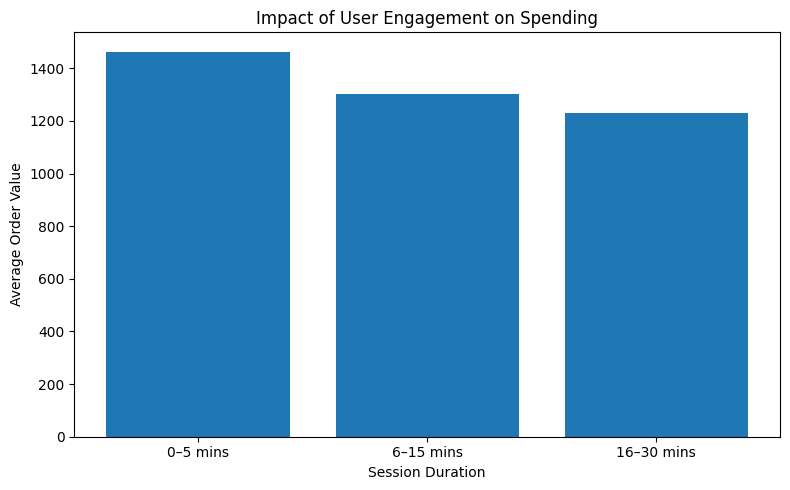

In [14]:
plt.figure(figsize=(8,5))
plt.bar(
    behaviour_summary["session_bucket"],
    behaviour_summary["avg_order_value"]
)

plt.xlabel("Session Duration")
plt.ylabel("Average Order Value")
plt.title("Impact of User Engagement on Spending")
plt.tight_layout()
plt.show()


### Business Insight
The chart shows that average order value is highest for short browsing sessions (0–5 minutes) and gradually declines as session duration increases. This suggests that highly engaged users are not necessarily spending more; instead, quick and decisive purchases tend to generate higher order values. Longer sessions may indicate browsing, comparison, or decision friction rather than purchase intent. Improving product discoverability and reducing decision complexity could help convert longer browsing sessions into higher-value purchases.
